In [1]:
from nrem_analysis.constant import MOUSE_IDS_TTX, PROCESSED_DIR, RAW_DIR, FIGURES_DIR

import re
import numpy as np
import pynapple as nap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat

def unwrap_epochs(data: nap.Tsd) -> nap.Tsd:
    d = data.d.copy()
    t = data.t

    for start, end in zip(
        data.time_support.start,
        data.time_support.end,
    ):
        i = np.searchsorted(t, start, side="left")
        j = np.searchsorted(t, end, side="right")
        d[i:j] = np.unwrap(d[i:j])

    return nap.Tsd(t=t, d=d, time_support=data.time_support)

In [2]:
control_v, ttx_v = [], []

for mouse_id in MOUSE_IDS_TTX:
    data_dir = PROCESSED_DIR / "ttx" / mouse_id
    
    print(f"Processing {mouse_id}")
    session = nap.load_file(data_dir / "sessions.npz")
    rhd = nap.load_file(data_dir / "rem_hd.npz")
    
    ttx_onset = session[session["label"] == "ttx"].start.item()
    rem_hd = np.rad2deg(unwrap_epochs(np.deg2rad(rhd))) 
    velocity = rem_hd.derivative()

    # get control, ttx mask
    rem_epochs = rem_hd.time_support
    control_mask = np.all(rem_epochs.values < ttx_onset, axis=1)
    control_epochs = rem_epochs[control_mask]
    ttx_epochs = rem_epochs[~control_mask]

    control_v.append(velocity.restrict(control_epochs).bin_average(0.1).d)
    ttx_v.append(velocity.restrict(ttx_epochs).bin_average(0.1).d)

control_v = np.concatenate(control_v)
ttx_v = np.concatenate(ttx_v)

Processing 83b
Processing 85b
Processing 116b
Processing 119b


In [3]:
condition = np.concatenate([np.full(control_v.shape, "Control"), np.full(ttx_v.shape, "TTX")])
results = pd.DataFrame(np.concatenate([control_v, ttx_v]), columns=['velocity'])
results['condition'] = condition
results

,velocity,condition
0,10.000153,Control
1,-110.000153,Control
2,-70.000000,Control
3,30.000153,Control
4,464.999924,Control
...,...,...
74345,100.000000,TTX
74346,105.001221,TTX
74347,145.001221,TTX
74348,0.000000,TTX


In [4]:
from scipy.stats import kstest

stats = kstest(control_v, ttx_v)
stats

KstestResult(statistic=np.float64(0.106506137357813), pvalue=np.float64(6.148219009545087e-162), statistic_location=np.float64(50.00000000000022), statistic_sign=np.int8(1))

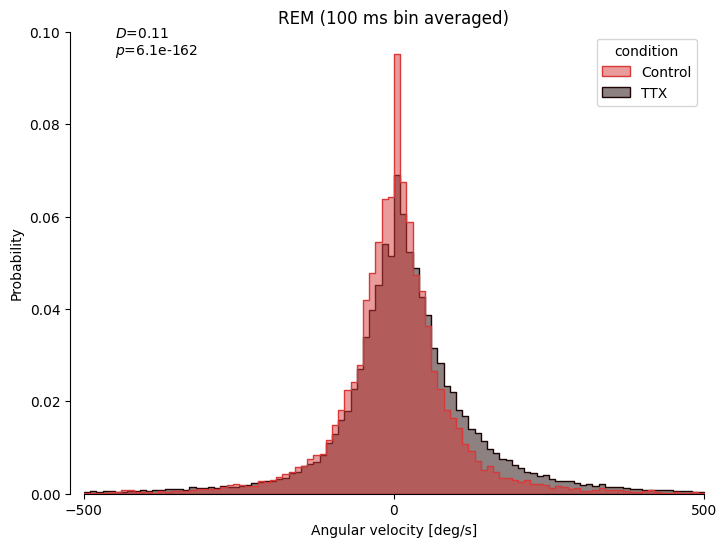

In [ ]:
f, ax = plt.subplots(figsize=(8, 6))

mask = np.abs(results['velocity']) < 500
sns.histplot(
    data=results[mask],
    x='velocity', hue='condition',
    common_norm=False,
    element='step',
    stat='probability',
    bins=100,
    alpha=0.5,
    palette={"Control": "#d73939", "TTX": "#1d0505ff"},
    ax=ax,
    )

ax.set_xlim(-500, 500)
ax.set_xticks((-500, 0, 500))
ax.set_ylim(0, 0.1)
ax.set_xlabel('Angular velocity [deg/s]')
ax.set_ylabel('Probability')

sns.despine()
ax.spines['left'].set_position(('outward', 10))
ax.set_title('REM (100 ms bin averaged)')
ax.text(
    0.05, 0.95,
    f'$D$={stats.statistic:.2f}\n$p$={stats.pvalue:.2g}',
    transform=ax.transAxes)

# plt.savefig(FIGURES_DIR / "ttx" / "rem_velocity_all.png", format='png', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "ttx" / "rem_velocity_all.svg", format='svg', bbox_inches='tight')

Text(0.95, 0.05, '$D$=0.11\n$p$=6.1e-162')

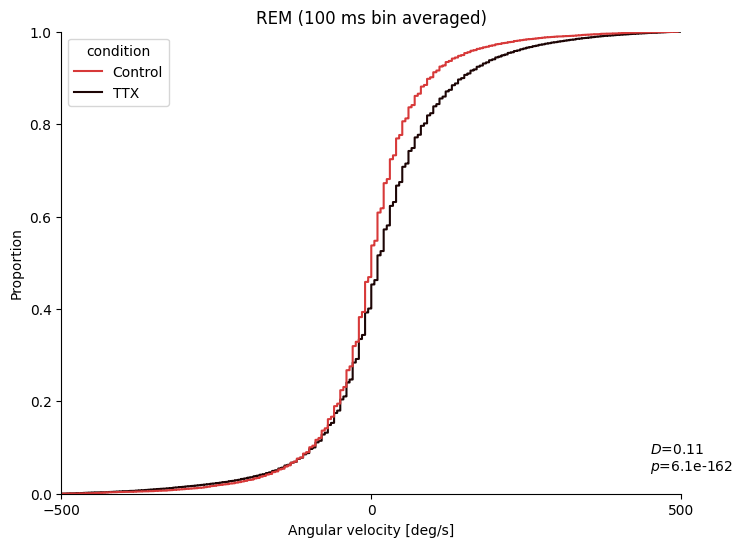

In [29]:
f, ax = plt.subplots(figsize=(8, 6))

mask = np.abs(results['velocity']) < 500
sns.ecdfplot(
    data=results[mask],
    x='velocity', hue='condition',
    stat='proportion',
    palette={"Control": "#d73939", "TTX": "#1d0505ff"},
    ax=ax,
)

ax.set_xlim(-500, 500)
ax.set_xticks((-500, 0, 500))
ax.set_xlabel('Angular velocity [deg/s]')

sns.despine()
# ax.spines['left'].set_position(('outward', 10))
ax.set_title('REM (100 ms bin averaged)')
ax.text(
    0.95, 0.05,
    f'$D$={stats.statistic:.2f}\n$p$={stats.pvalue:.2g}',
    transform=ax.transAxes)

# plt.savefig(FIGURES_DIR / "ttx" / "rem_velocity_all.png", format='png', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "ttx" / "rem_velocity_all.svg", format='svg', bbox_inches='tight')


Text(0.5, 1.0, 'Derivitave of REM HD epoch')

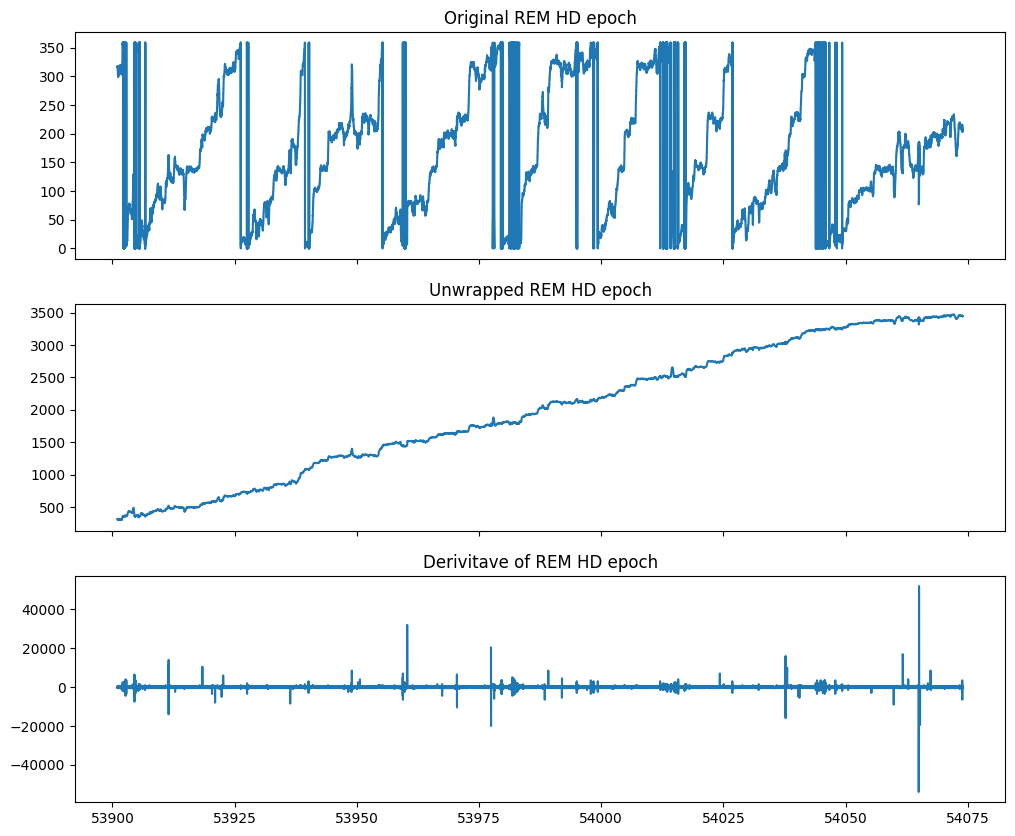

In [326]:
f, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ep = rem_hd.time_support[-1]

axs[0].plot(rhd.restrict(ep))
axs[0].set_title('Original REM HD epoch')

axs[1].plot(rem_hd.restrict(ep))
axs[1].set_title('Unwrapped REM HD epoch')

axs[2].plot(velocity.restrict(ep))
axs[2].set_title('Derivitave of REM HD epoch')
# axs[2].set_ylim(-5000, 1000)

Text(0.5, 1.0, 'Derivitave of REM HD epoch')

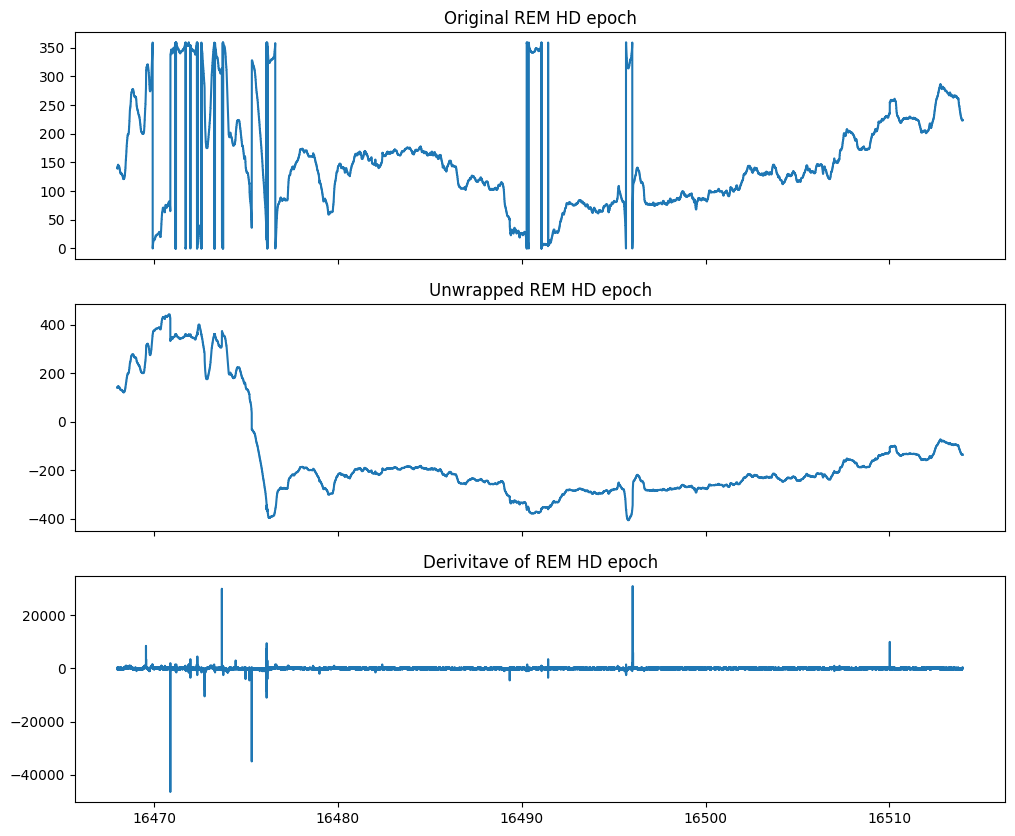

In [320]:
f, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ep = rem_hd.time_support[0]

axs[0].plot(rhd.restrict(ep))
axs[0].set_title('Original REM HD epoch')

axs[1].plot(rem_hd.restrict(ep))
axs[1].set_title('Unwrapped REM HD epoch')

axs[2].plot(velocity.restrict(ep))
axs[2].set_title('Derivitave of REM HD epoch')
# axs[2].set_ylim(-500, 500)